In [21]:
import pandas as pd
import numpy as np
import os
import math
from pathlib import Path
from matplotlib import pyplot as plt
idx = pd.IndexSlice
import xarray as xr
from read_mym import read_mym_df

from constants_BUMA import(
    SCENARIO_SELECT, FILE_ADDITION,
    REGIONS, REGIONS_RANGE,
    START_YEAR, END_YEAR, HIST_YEAR, YEARS, YEAR_LIST_SVA,
    INFLATION, 
    FLAG_ALPHA, FLAG_EXPDEC,
    LOWCOMM,
    GOMPERTZ_EXPDEC,
    MINIMUM_COM
)


In [22]:
base_directory = Path("..", "IMAGE-Mat_old_version", "IMAGE-Mat", "BUMA")
database_directory = base_directory / "files_DB" / SCENARIO_SELECT
image_directory = base_directory / "files_IMAGE" / SCENARIO_SELECT
assert database_directory.is_dir(), database_directory
assert image_directory.is_dir()


In [23]:
#%% # Reading all csv files for buildings that are external to IMAGE

# 1) scenario independent data
# Avg_m2_cap; unit: m2/capita; meaning: average square meters per person (by region & rural/urban) 
avg_m2_cap: pd.DataFrame = pd.read_csv(base_directory.joinpath('files_DB','Average_m2_per_cap.csv')) 

# 1) scenario dependent data 
# Housing_type; unit: %; meaning: the share of the PEOPLE living in a particular building type (by region & by area) 
housing_type: pd.DataFrame = pd.read_csv(database_directory.joinpath('Housing_type_dynamic.csv'), index_col = [0,1,2]) 
# Building_materials; unit: kg/m2; meaning: the average material use per square meter (by building type, by region & by area)
building_materials: pd.DataFrame = pd.read_csv(database_directory.joinpath('Building_materials' + FILE_ADDITION + '.csv'), index_col = [0,1,2]) 
# 7 building materials in 4 commercial building types; unit: kg/m2; meaning: the average material use per square meter (by commercial building type)
materials_commercial: pd.DataFrame = pd.read_csv(database_directory.joinpath('materials_commercial' + FILE_ADDITION + '.csv'), index_col = [0,1])  

# load IMAGE data-files (MyM file format)
floorspace: pd.DataFrame = read_mym_df(image_directory.joinpath("res_Floorspace.out"))
floorspace = floorspace[['time','DIM_1',2,3]].rename(columns={"DIM_1": "Region", 'time':'t', 2:'Urban', 3:'Rural'})
# the other columns are average per capita floorspace per quintile (we also exclude the average per capita floorspace of the total population in column 1, 
# because we use the urban & rural specific totals)
floorspace = floorspace[floorspace.Region != REGIONS + 1] #removing region 27
floorspace = floorspace[floorspace['t'].isin(list(range(START_YEAR, END_YEAR+1)))]
# remove all data beyond 2060 to save runtime, we have not yet generated scenario results beyond 2060

# Pop; unit: million of people; meaning: global population (over time, by region)             
population: pd.DataFrame = pd.read_csv(image_directory.joinpath('pop.csv'), index_col = [0]) 
# rurpop; unit: %; meaning: the share of people living in rural areas (over time, by region)
rural_population: pd.DataFrame = pd.read_csv(image_directory. joinpath('rurpop.csv'), index_col = [0])
# load historic population development
historic_population = pd.read_csv(base_directory / 'files_initial_stock' /'hist_pop.csv', index_col = [0])  
# initial population as a percentage of the 1970 population; unit: %; according to the Maddison Project Database (MPD) 2018 (Groningen University)

# we use the inflation corrected SVA to adjust for the fact that IMAGE provides gdp/cap in 2005 US$
service_value_added_2005: pd.DataFrame = pd.read_csv(image_directory.joinpath('sva_pc.csv'), index_col = [0])
service_value_added = service_value_added_2005 * INFLATION
# added cubic interpolation to the sva_pc (presumed linear interpolation between 5-year original data caused sawtooth demand/inflow throughout the scenario projection after 2025)
service_value_added = service_value_added.loc[YEAR_LIST_SVA,:].reindex(list(range(1970, END_YEAR + 1,1))).interpolate(method='cubic') 

# Load fitted regression parameters
if FLAG_ALPHA == 0:
    gompertz = pd.read_csv(base_directory / 'files_commercial/Gompertz_parameters.csv', index_col = [0])
else:
    gompertz = pd.read_csv(base_directory / 'files_commercial/Gompertz_parameters_alpha.csv', index_col = [0])


In [24]:
# Interpolate population and rural population data (fills in missing years with cubic interpolation)
rural_population = rural_population.reindex(YEARS).interpolate(method='cubic')
population = population.reindex(YEARS).interpolate(method='cubic')
# Remove 1st year, to ensure same Table size as floorspace data (from 1971)
population = population.iloc[1:]
rural_population = rural_population.iloc[1:]

#pre-calculate urban population
urban_population = 1 - rural_population    
# urban population is 1 - the fraction of people living in rural areas (rurpop)

# also interpolate housing type data
index_ht = pd.MultiIndex.from_product([list(range(HIST_YEAR, END_YEAR + 1)), 
                                       list(range(1,REGIONS + 1)), 
                                       ['Urban', 'Rural'] ]) 
housing_type = pd.DataFrame(np.nan, index=index_ht, columns=housing_type.columns)

for year in list(housing_type.index.levels[0]):
    housing_type.loc[idx[year,:,:],:] = housing_type.loc[idx[year,:,:],:]
    
for region in list(range(1,REGIONS + 1)):
    for area in ['Urban', 'Rural']:
        housing_types_interpolated = housing_type.loc[idx[:,region,area],:].interpolate(method='linear', limit_direction='both')
        housing_type.loc[idx[:,region,area],:] = housing_types_interpolated.values                                                     
       

In [44]:

# Select gompertz curve paramaters for the total commercial m2 demand (stock)
alpha, beta, gamma = (
    (gompertz['All']['a'], gompertz['All']['b'], gompertz['All']['c'])
    if FLAG_EXPDEC == 0 else GOMPERTZ_EXPDEC          
)
alpha_low = alpha * LOWCOMM                                    # alpha multiplied with a factor, lowering the maximum per capita commecrial floorspace between (2020 and 2050) 

# find the total commercial m2 stock (in Millions of m2)
commercial_m2_cap = pd.DataFrame(index=YEARS, columns=REGIONS_RANGE)
commercial_m2_cap_low = commercial_m2_cap.copy()

# Compute commercial floorspace using Gompertz curves
for year in YEARS:
    for region in REGIONS_RANGE:
        exp_factor = math.exp((-gamma/1000) * service_value_added[str(region)][year])
        if FLAG_EXPDEC == 0:
            commercial_m2_cap[region][year] = alpha * math.exp(-beta * exp_factor)
            commercial_m2_cap_low[region][year] = alpha_low * math.exp(-beta * exp_factor)
        else:
            commercial_m2_cap[region][year] = max(0.542, alpha - beta * exp_factor)

# commercial floorspace is scaled here (in case lowComm is not 1)
scale_comm = pd.Series([1.0, 0.0], index=[2020, 2060], name='time').reindex(YEARS).interpolate(method='linear', limit=300, limit_direction='both')
commercial_m2_cap    = commercial_m2_cap.mul(scale_comm, axis=0) + commercial_m2_cap_low.mul((1-scale_comm), axis=0)


C:\Users\5982758\AppData\Local\Temp\ipykernel_11140\474694530.py:17: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  commercial_m2_cap[region][year] = alpha * math.exp(-beta * exp_factor)
C:\Users\5982758\AppData\Local\Temp\ipykernel_11140\474

In [60]:

# Subdivide the total across Offices, Retail+, Govt+ & Hotels+
types = ["Office", "Retail+", "Hotels+", "Govt+"]
index = pd.MultiIndex.from_product([types, REGIONS_RANGE, YEARS], names=["Type", "Region", "Year"])
commercial_m2_cap_all = pd.DataFrame(index=index, columns=["m2_per_cap"]).fillna(0)

#TODO move to a util file
# Define a function to calculate Gompertz growth
def gompertz_value(category, region, year, sva_data):
    """Calculate the Gompertz value for a given category, region, and year."""
    params = gompertz[category]
    return params['a'] * math.exp(-params['b'] * math.exp((-params['c'] / 1000) * sva_data[str(region)][year]))

for year in YEARS:
    for region in REGIONS_RANGE:
        # Calculate floorspace for all types and update the minimum values
        floorspace_commercial_list = {}
        for type_ in types:
            #value = gompertz_value(type_, region, year, service_value_added)
            params = gompertz[type_]
            value = params['a'] * math.exp(-params['b'] * math.exp((-params['c'] / 1000) * service_value_added[str(region)][year]))
            floorspace_commercial_list[type_] = value
            MINIMUM_COM[type_] = min(MINIMUM_COM[type_], value)

        # Sum all floorspace values for normalization
        commercial_sum = sum(floorspace_commercial_list.values())

        # Calculate and assign the floorspace for each type
        for type_ in types:
            commercial_m2_cap_all.loc[(type_, region, year), "m2_per_cap"] = (
                commercial_m2_cap.loc[year, region] * (floorspace_commercial_list[type_] / commercial_sum)
            )


C:\Users\5982758\AppData\Local\Temp\ipykernel_11140\315710021.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  commercial_m2_cap_all = pd.DataFrame(index=index, columns=["m2_per_cap"]).fillna(0)
C:\Users\5982758\AppData\Local\Temp\ipykernel_11140\315710021.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  commercial_m2_cap_all.loc[(type_, region, year), "m2_per_cap"] = (
C:\Users\5982758\AppData\Local\Temp\ipykernel_11140\315710021.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.9206405464508888' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  commercial_m2_cap_all.loc[(type_, region, year), "m2_per_cap"] = 

In [62]:
commercial_m2_cap_all = commercial_m2_cap_all.unstack("Type")

m2_per_cap                              
Type             Govt+   Hotels+    Office   Retail+
Region Year                                         
1      1971   5.025620  0.543599  0.920641  0.945211
       1972   5.216704  0.580083  1.004135  1.046878
       1973   5.266886  0.589926  1.026827  1.074881
       1974   5.299047  0.596294  1.041539  1.093123
       1975   5.470987  0.631137  1.122472  1.194652
...                ...       ...       ...       ...
26     2056   1.477656  0.097120  0.089558  0.071755
       2057   1.508801  0.100542  0.094784  0.076403
       2058   1.541461  0.104189  0.100456  0.081488
       2059   1.575573  0.108065  0.106602  0.087041
       2060   1.611072  0.112176  0.113247  0.093096

[2340 rows x 4 columns]

In [38]:
floorspace.set_index(["t", "Region"])

Urban     Rural
t    Region                    
1971 1       24.98800  31.99836
     2       25.88334  33.24847
     3       13.08842  17.10604
     4       13.04863  17.35473
     5       11.50818  15.08839
...               ...       ...
2060 22      21.52648  27.89780
     23      42.00000  49.00000
     24      30.00000  35.00000
     25      18.37338  24.10208
     26      14.52202  18.98492

[2340 rows x 2 columns]

In [64]:
commercial_m2_cap_all

m2_per_cap
Type   Region Year            
Office 1      1971    0.920641
              1972    1.004135
              1973    1.026827
              1974    1.041539
              1975    1.122472
...                        ...
Govt+  26     2056    1.477656
              2057    1.508801
              2058    1.541461
              2059    1.575573
              2060    1.611072

[9360 rows x 1 columns]

In [26]:
floorspace_dataset = floorspace.set_index(["t", "Region"]).to_xarray()

In [27]:
floorspace_array = xr.DataArray(0.0, dims=("t", "Region", "type"), coords={
    "t": floorspace_dataset.coords["t"],
    "Region": floorspace_dataset.coords["Region"],
    "type": ["Urban", "Rural", "Office", "Retail+", "Hotels+", "Govt+"],
})

In [28]:
for data_name, data_var in floorspace_dataset.data_vars.items():
    floorspace_array.loc[:, :, data_name] = data_var

In [29]:
interp_coor = floorspace_array.sel(t=range(1971, 1981)).coords
trend_1971_1981 = xr.DataArray(
    floorspace_array.sel(t=range(1971, 1981)).to_numpy()/floorspace_array.sel(t=range(1972, 1982)).to_numpy(),
    dims=("t", "Region", "type"),
    coords=interp_coor
)

In [30]:
avg_trend_1971_1981 = trend_1971_1981.mean(["t", "Region"])

In [31]:
min_floorspace = floorspace_array.min(["t", "Region"])

In [32]:
start_year = 1820
end_year = 1971
delta_year = end_year - start_year
fraction_interpol = avg_trend_1971_1981.values.reshape(1, -1)**(delta_year - np.arange(end_year-start_year)).reshape(-1, 1)
reshaped_floor_1971 = floorspace_array.loc[1971, :, :].values.reshape(1, *floorspace_array.shape[1:])
interpol_floor_1820_1970_np = reshaped_floor_1971*fraction_interpol.reshape(fraction_interpol.shape[0], 1, -1)
where_too_low = np.where(interpol_floor_1820_1970_np < min_floorspace.values)
interpol_floor_1820_1970_np[where_too_low] = min_floorspace.values[where_too_low[-1]]
interpol_floor_1820_1970_xr = xr.DataArray(interpol_floor_1820_1970_np, dims=floorspace_array.dims,
                                           coords={
                                               "t": np.arange(start_year, end_year),
                                               "Region": floorspace_array.coords["Region"],
                                               "type": floorspace_array.coords["type"]
                                           })

In [33]:
far_start_year = 1721
interpol_floor_1721_1820 = np.linspace(0, interpol_floor_1820_1970_np[0, :, :], num=(start_year - far_start_year), endpoint=False)
interpol_floor_1721_1820_xr = xr.DataArray(interpol_floor_1721_1820,
                                           dims=floorspace_array.dims,
                                           coords={
                                               "t": np.arange(far_start_year, start_year),
                                               "Region": floorspace_array.coords["Region"],
                                               "type": floorspace_array.coords["type"]
                                           })

In [34]:
floorspace_xr = xr.concat((interpol_floor_1721_1820_xr, interpol_floor_1820_1970_xr, floorspace_array), dim="t")

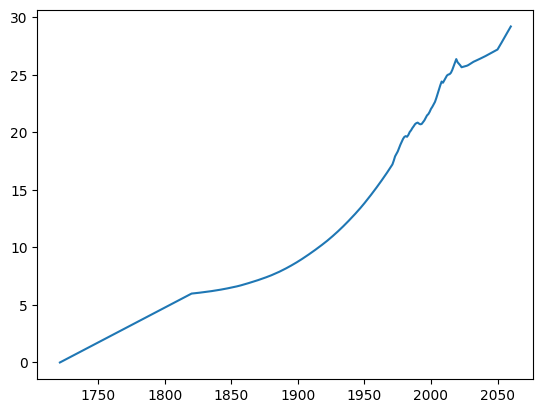

In [35]:
plt.plot(floorspace_xr.coords["t"], floorspace_xr.mean(["Region", "type"]))
plt.show()